# Week 1 — Minecraft Knowledge Agent

**도메인**: 마인크래프트 지식 에이전트  
**목표**: StateGraph로 직접 ReAct 루프를 구성하고, 도메인 도구 3개를 활용하여 구조화된 응답 반환

## 그래프 구조
```
START → agent → should_continue() → tools → agent (루프)
                                  → format_output → END
```
- **agent**: LLM이 도구 호출 여부를 직접 판단
- **tools**: ToolNode가 실제 도구 실행 (오류 처리 포함)
- **format_output**: 대화 기록 → Pydantic 구조화 응답
- **조건부 엣지**: `tool_calls` 유무로 tools / format_output 분기

In [1]:
import sys
import os


sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())
os.environ['LANGSMITH_TRACING'] = 'false'
os.environ['LANGSMITH_TRACING_V2'] = 'false'

## 1. 그래프 로드 및 시각화

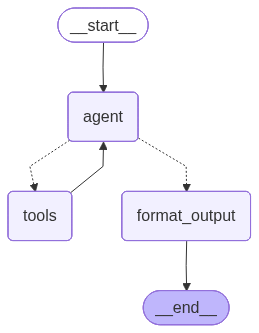

In [2]:
from graph import graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## 2. 헬퍼 함수 정의

In [14]:
from langchain_core.messages import HumanMessage
from schema import MinecraftAgentResponse


def run_agent(question: str, thread_id: str="default") -> None:
    for state in graph.stream(
        {'messages': [HumanMessage(content=question)], 'structured_output': None},
        config={'configurable': {'thread_id': thread_id}, 'recursion_limit': 15},
        stream_mode="updates",
    ):
        print(state)
        if state.get('format_output'):
            resp: MinecraftAgentResponse = state['format_output']['structured_output']
            tools = ', '.join(resp.tools_used) if resp.tools_used else '없음'
            print(f'A: {resp.answer}')
            print(f'   (사용 도구: {tools} | 신뢰도: {resp.confidence:.0%})')

print('헬퍼 함수 정의 완료')

헬퍼 함수 정의 완료


## 3. 테스트 질문

In [15]:
run_agent('크리퍼에 대해 알려줘.', thread_id='user_1')

{'agent': {'messages': [AIMessage(content='크리퍼는 마인크래프트에서 적대적인 몹으로, 20 HP의 체력을 가지고 있습니다. 이 몹의 주된 공격 방식은 폭발이며, 일반 난이도에서 최대 49의 폭발 데미지를 입힐 수 있습니다. 만약 크리퍼가 번개에 맞아 충전되면, 그 데미지는 최대 98에 이릅니다.\n\n행동 패턴은 소리 없이 플레이어에게 접근하며, 1.5초 후에 폭발하는 방식입니다. 크리퍼는 고양이나 오실롯과 같은 동물을 무서워하여, 이들이 주변에 있으면 접근하지 않습니다.\n\n전투할 때는 검으로 한번 공격한 뒤 즉시 후퇴하여 폭발을 피하는 것이 좋습니다. 활을 활용해 원거리에서 안전하게 처리할 수도 있으며, 고양이를 배치하면 크리퍼의 접근을 차단할 수 있습니다. \n\n크리퍼는 처치 시 화약(0~2개)을 드롭하며, 스켈레톤에게 처치될 경우 음악 디스크를 드롭하기도 합니다. 주로 어두운 지역(빛 레벨 0)에서 스폰되니, 조명에 주의를 기울여야 합니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 271, 'prompt_tokens': 3021, 'total_tokens': 3292, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 2944}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_84283cb50c', 'id': 'chatcmpl-Dgkm126sBv2C9a5wkAwCC

In [16]:
run_agent('거기서 드롭되는 아이템으로 뭘 만들 수 있어?', thread_id='user_1')

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 3315, 'total_tokens': 3333, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 3200}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_84283cb50c', 'id': 'chatcmpl-DgkmFwMAgh1TQT61U1q9Pj8nz58Hj', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e398c-55aa-7d93-b8d7-c2bfa21bdf4d-0', tool_calls=[{'name': 'get_crafting_recipe', 'args': {'item_name': '화약'}, 'id': 'call_66duhsZr8W6lIb1FrcMuUNzz', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 3315, 'output_tokens': 18, 'total_tokens': 3333, 'input_token_details': {'audio': 0, 'cache_read': 3200}, 'output_token_details'

In [17]:
run_agent('거기서 드롭되는 아이템으로 뭘 만들 수 있어?', thread_id='user_2')

{'agent': {'messages': [AIMessage(content='어떤 몹이나 아이템을 말씀하시는지 구체적으로 알려주시면, 그 드롭 아이템을 이용한 제작법을 안내해 드릴 수 있습니다. 예를 들어, 특정 몹의 이름이나 아이템을 언급해 주시면 그에 따른 정보를 제공하도록 하겠습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 617, 'total_tokens': 682, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_84283cb50c', 'id': 'chatcmpl-DgkmQL83v7XWtzJIbvVND3HltmQCA', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e398c-836a-74a1-b2be-30f139491b13-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 617, 'output_tokens': 65, 'total_tokens': 682, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'r

## 4. 그래프 노드/엣지 구조 확인

In [18]:
g = graph.get_graph()

print('노드 목록:')
for node in g.nodes:
    print(f'  - {node}')

print('\n엣지 목록:')
for edge in g.edges:
    cond = f' (조건: {edge.data})' if edge.data else ''
    print(f'  {edge.source} → {edge.target}{cond}')

노드 목록:
  - __start__
  - agent
  - tools
  - format_output
  - __end__

엣지 목록:
  __start__ → agent
  agent → format_output
  agent → tools
  tools → agent
  format_output → __end__
